In [152]:
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import numpy as np

In [153]:
df = pd.read_csv("/content/sample_1.csv").dropna()

In [154]:
df

,c1,c2
0,-7.430860,-7.899923
1,-7.912123,-7.341576
2,-1.522144,7.549274
3,4.378661,3.291702
4,-9.325377,-8.089813
...,...,...
295,-3.890390,9.465124
296,3.645085,1.300952
297,-4.438178,9.235847
298,-6.857525,-4.868385


In [155]:
df.shape

(300, 2)

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   c1      300 non-null    float64
 1   c2      300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


In [157]:
df.drop_duplicates()

,c1,c2
0,-7.430860,-7.899923
1,-7.912123,-7.341576
2,-1.522144,7.549274
3,4.378661,3.291702
4,-9.325377,-8.089813
...,...,...
295,-3.890390,9.465124
296,3.645085,1.300952
297,-4.438178,9.235847
298,-6.857525,-4.868385


In [158]:
x = df

In [159]:
from sklearn.model_selection import train_test_split
x_train, x_test = train_test_split(x, test_size=0.3, random_state=7)
x_train.shape, x_test.shape

((210, 2), (90, 2))

In [160]:
km = KMeans(n_clusters=3,random_state=7,max_iter=100)
km.fit(x_train)

KMeans(max_iter=100, n_clusters=3, random_state=7)

In [161]:
km.cluster_centers_

array([[-6.89102241, -7.04992131],
       [-2.65392001,  9.04028015],
       [ 4.52734878,  2.04376566]])

In [162]:
y_pred = km.predict(x_test)
y_pred

array([2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, 0, 2, 1, 1, 2, 1, 0,
       0, 0, 1, 2, 1, 2, 2, 1, 2, 0, 1, 1, 1, 1, 1, 2, 2, 1, 2, 0, 2, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 2, 0, 2, 2, 1, 0,
       2, 1, 0, 0, 2, 0, 1, 2, 2, 0, 1, 0, 2, 0, 1, 0, 2, 0, 0, 1, 2, 2,
       2, 1], dtype=int32)

In [163]:
#how we decide the k
#l-bow method



/tmp/ipykernel_571/1142490242.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df.iloc[:, 0], df.iloc[:, 1], cmap='viridis')


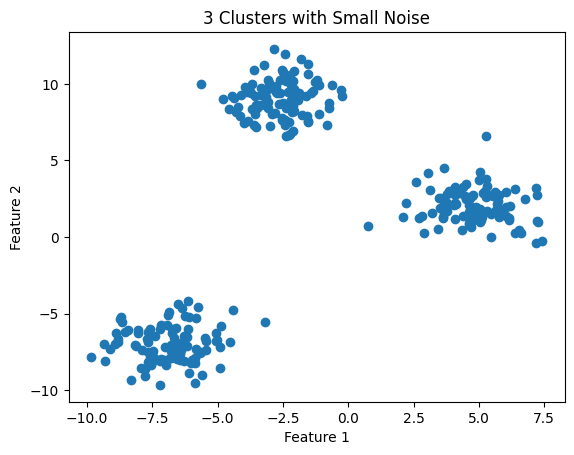

In [164]:
# Plot
import matplotlib.pyplot as plt
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], cmap='viridis')

plt.title("3 Clusters with Small Noise")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [165]:
inertia_values = []
for k in range(2,11):
    km = KMeans(k,random_state=7)
    km.fit(x_train)
    inertia_values.append(km.inertia_)

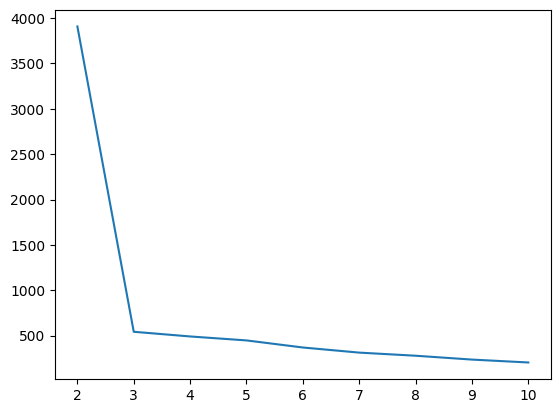

In [166]:
import matplotlib.pyplot as plt
plt.plot(list(range(2,11)), inertia_values)

In [167]:
from sklearn.metrics import silhouette_score
# two parameters to silhouette_score
# X : X_test data
# labels : cluster numbers predicted by the algorithm
y_pred = km.predict(x_test)
silhouette_score(x_test, y_pred)

np.float64(0.2794065508842352)